## Collecting Test Images

In [4]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import os

ticker = 'ADANIENT.NS'
folder = "test_images"
os.makedirs(folder, exist_ok=True)

print("Downloading data...")
df = yf.download(ticker, period="1y", interval="1d", 
                 progress=False, auto_adjust=False)

window = 25
saved = 0

for i in range(0, len(df) - window, window):
    df_win = df.iloc[i:i+window]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for idx, row in df_win.iterrows():
        date = mdates.date2num(idx)
        o = float(row['Open'].iloc[0])    
        h = float(row['High'].iloc[0])    
        l = float(row['Low'].iloc[0])     
        c = float(row['Close'].iloc[0])   
        
        color = 'green' if c > o else 'red'
        ax.plot([date, date], [l, h], color='black', lw=1)
        height = abs(c - o)
        bottom = min(o, c)
        ax.add_patch(Rectangle((date-0.2, bottom), 0.4, height, 
                              facecolor=color, edgecolor='black'))
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    plt.xticks(rotation=45)
    ax.grid(True, alpha=0.3)
    
    fname = f"image{saved:03d}.jpg"
    plt.savefig(os.path.join(folder, fname), dpi=150, bbox_inches='tight')
    plt.close()
    
    # print(f"{fname}")
    saved += 1

print(f"{saved} clean images in {folder}/")


10 clean images in test_images/


## Test result for YOLO 8n model


0: 352x512 2 Neutrals, 16.7ms
1: 352x512 1 Neutral, 16.7ms
2: 352x512 (no detections), 16.7ms
3: 352x512 1 DownTrend, 16.7ms
4: 352x512 1 UpTrend, 16.7ms
5: 352x512 2 Neutrals, 16.7ms
6: 352x512 1 DownTrend, 16.7ms
Speed: 7.1ms preprocess, 16.7ms inference, 3.1ms postprocess per image at shape (1, 3, 352, 512)


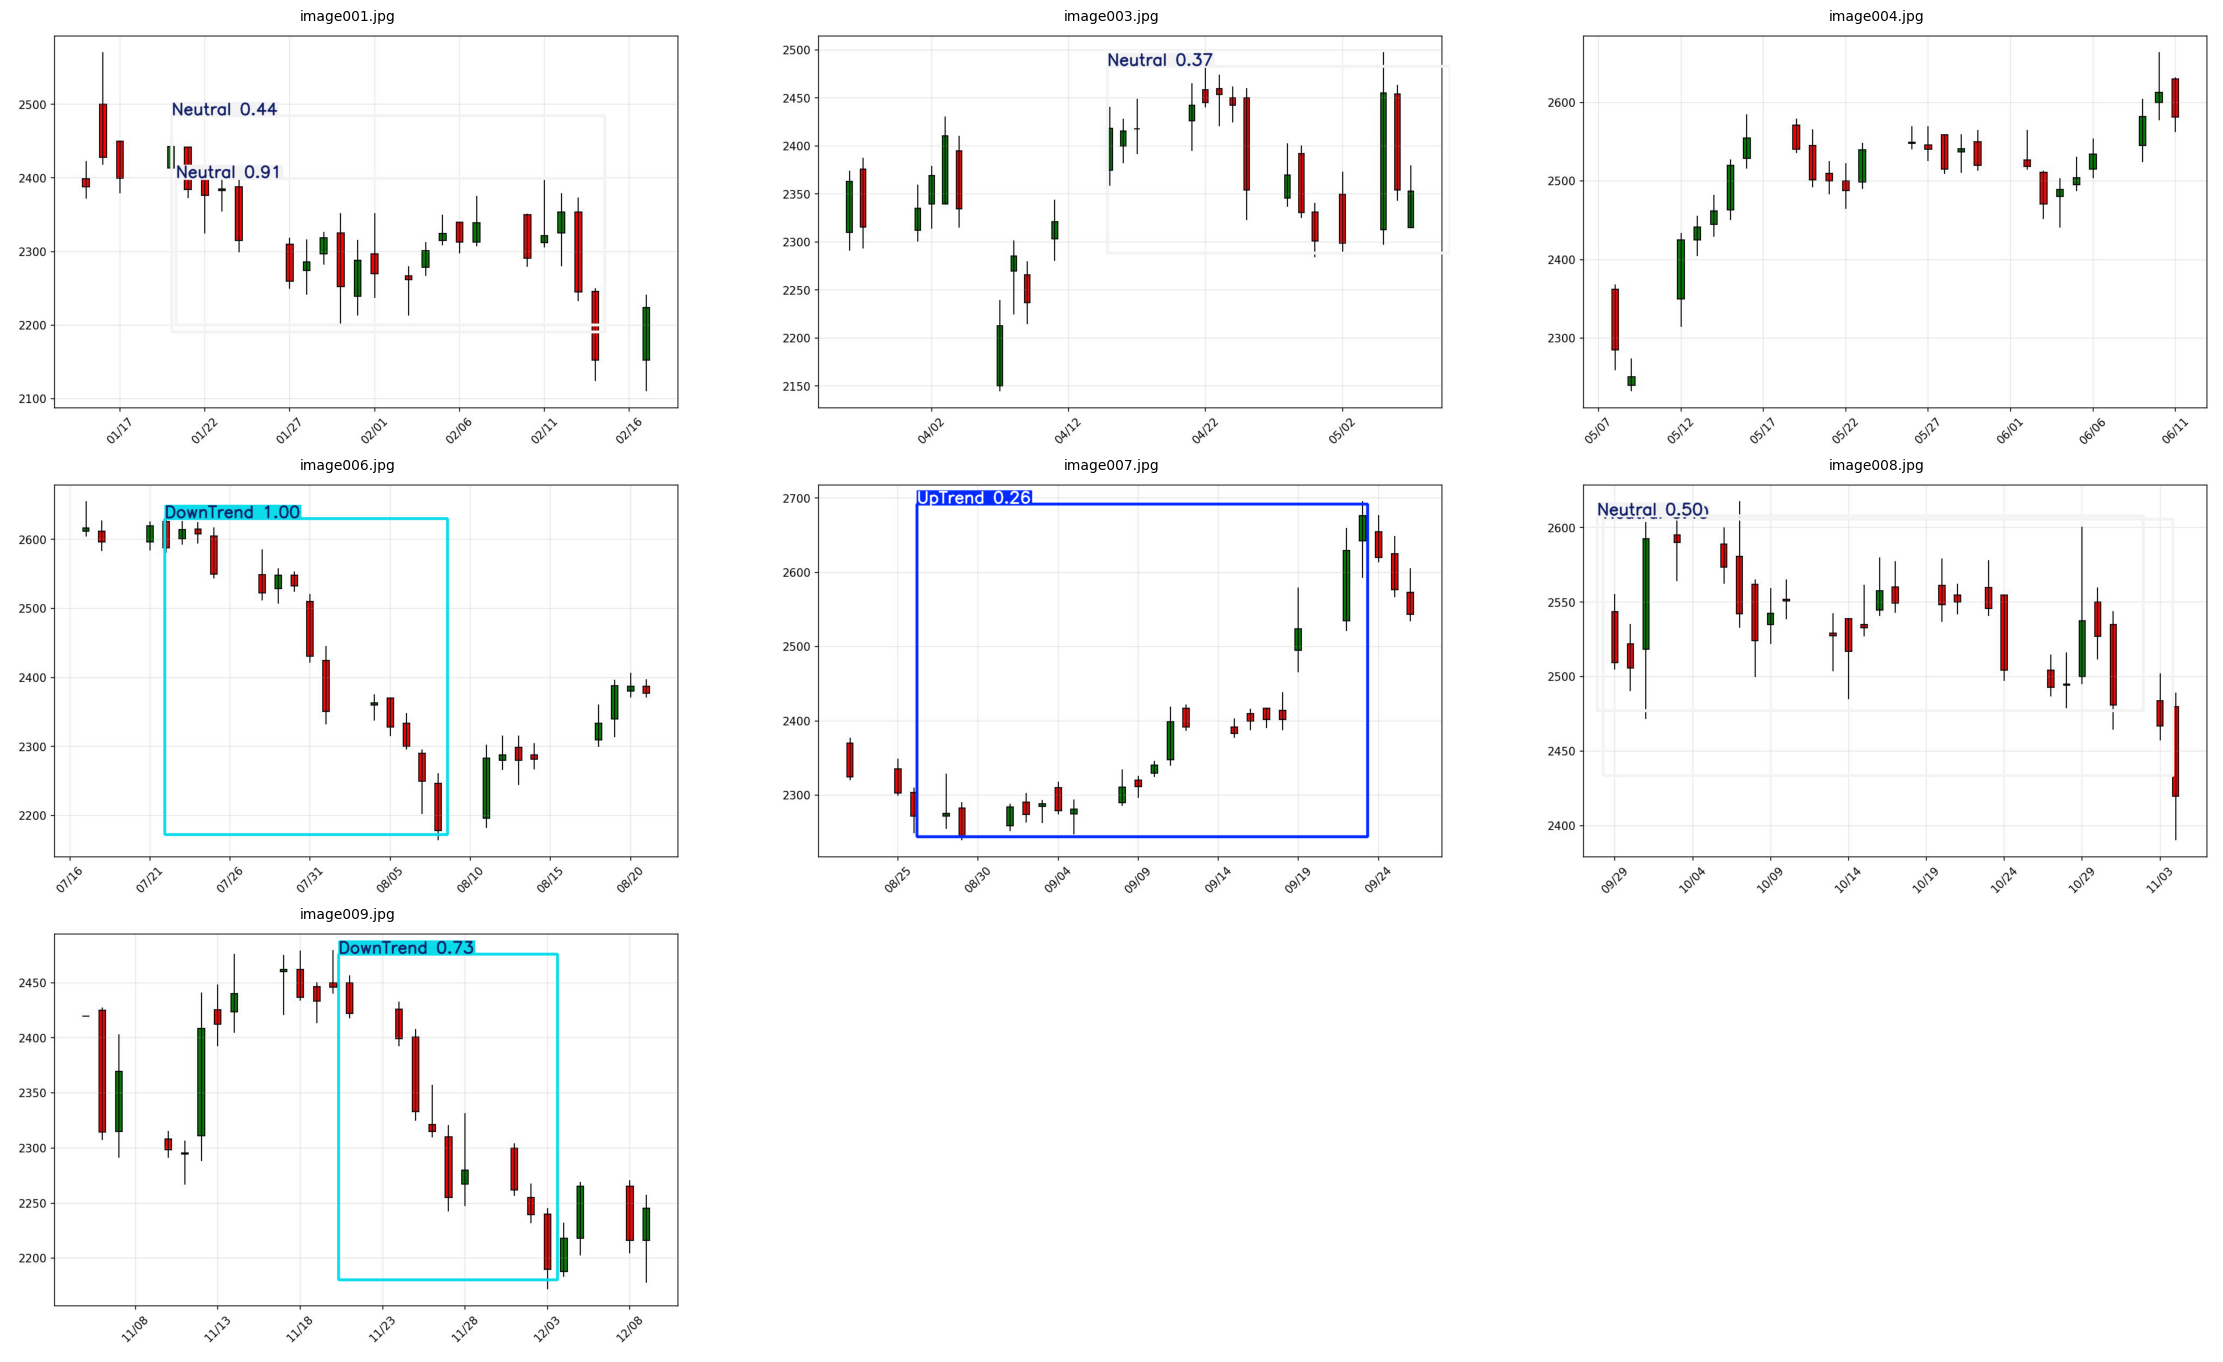

In [22]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("best8n.pt")

image_paths = [
    "test_images/image001.jpg",
    "test_images/image003.jpg",
    "test_images/image004.jpg",
    "test_images/image006.jpg",
    "test_images/image007.jpg",
    "test_images/image008.jpg",
    "test_images/image009.jpg"
]

results = model(image_paths)

plt.figure(figsize=(23, 18))  

rows, cols = 4, 3

for i, (r, path) in enumerate(zip(results, image_paths), start=1):
    img = r.plot()[:, :, ::-1]  # BGR -> RGB
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(path.split("/")[-1], fontsize=10)

plt.tight_layout(pad=0.3, w_pad=0.1, h_pad=0.3)
plt.show()


## Test result for YOLO 8s model


0: 352x512 1 Neutral, 16.4ms
1: 352x512 1 UpTrend, 16.4ms
2: 352x512 (no detections), 16.4ms
3: 352x512 1 DownTrend, 16.4ms
4: 352x512 (no detections), 16.4ms
5: 352x512 (no detections), 16.4ms
6: 352x512 1 DownTrend, 16.4ms
Speed: 3.7ms preprocess, 16.4ms inference, 1.8ms postprocess per image at shape (1, 3, 352, 512)


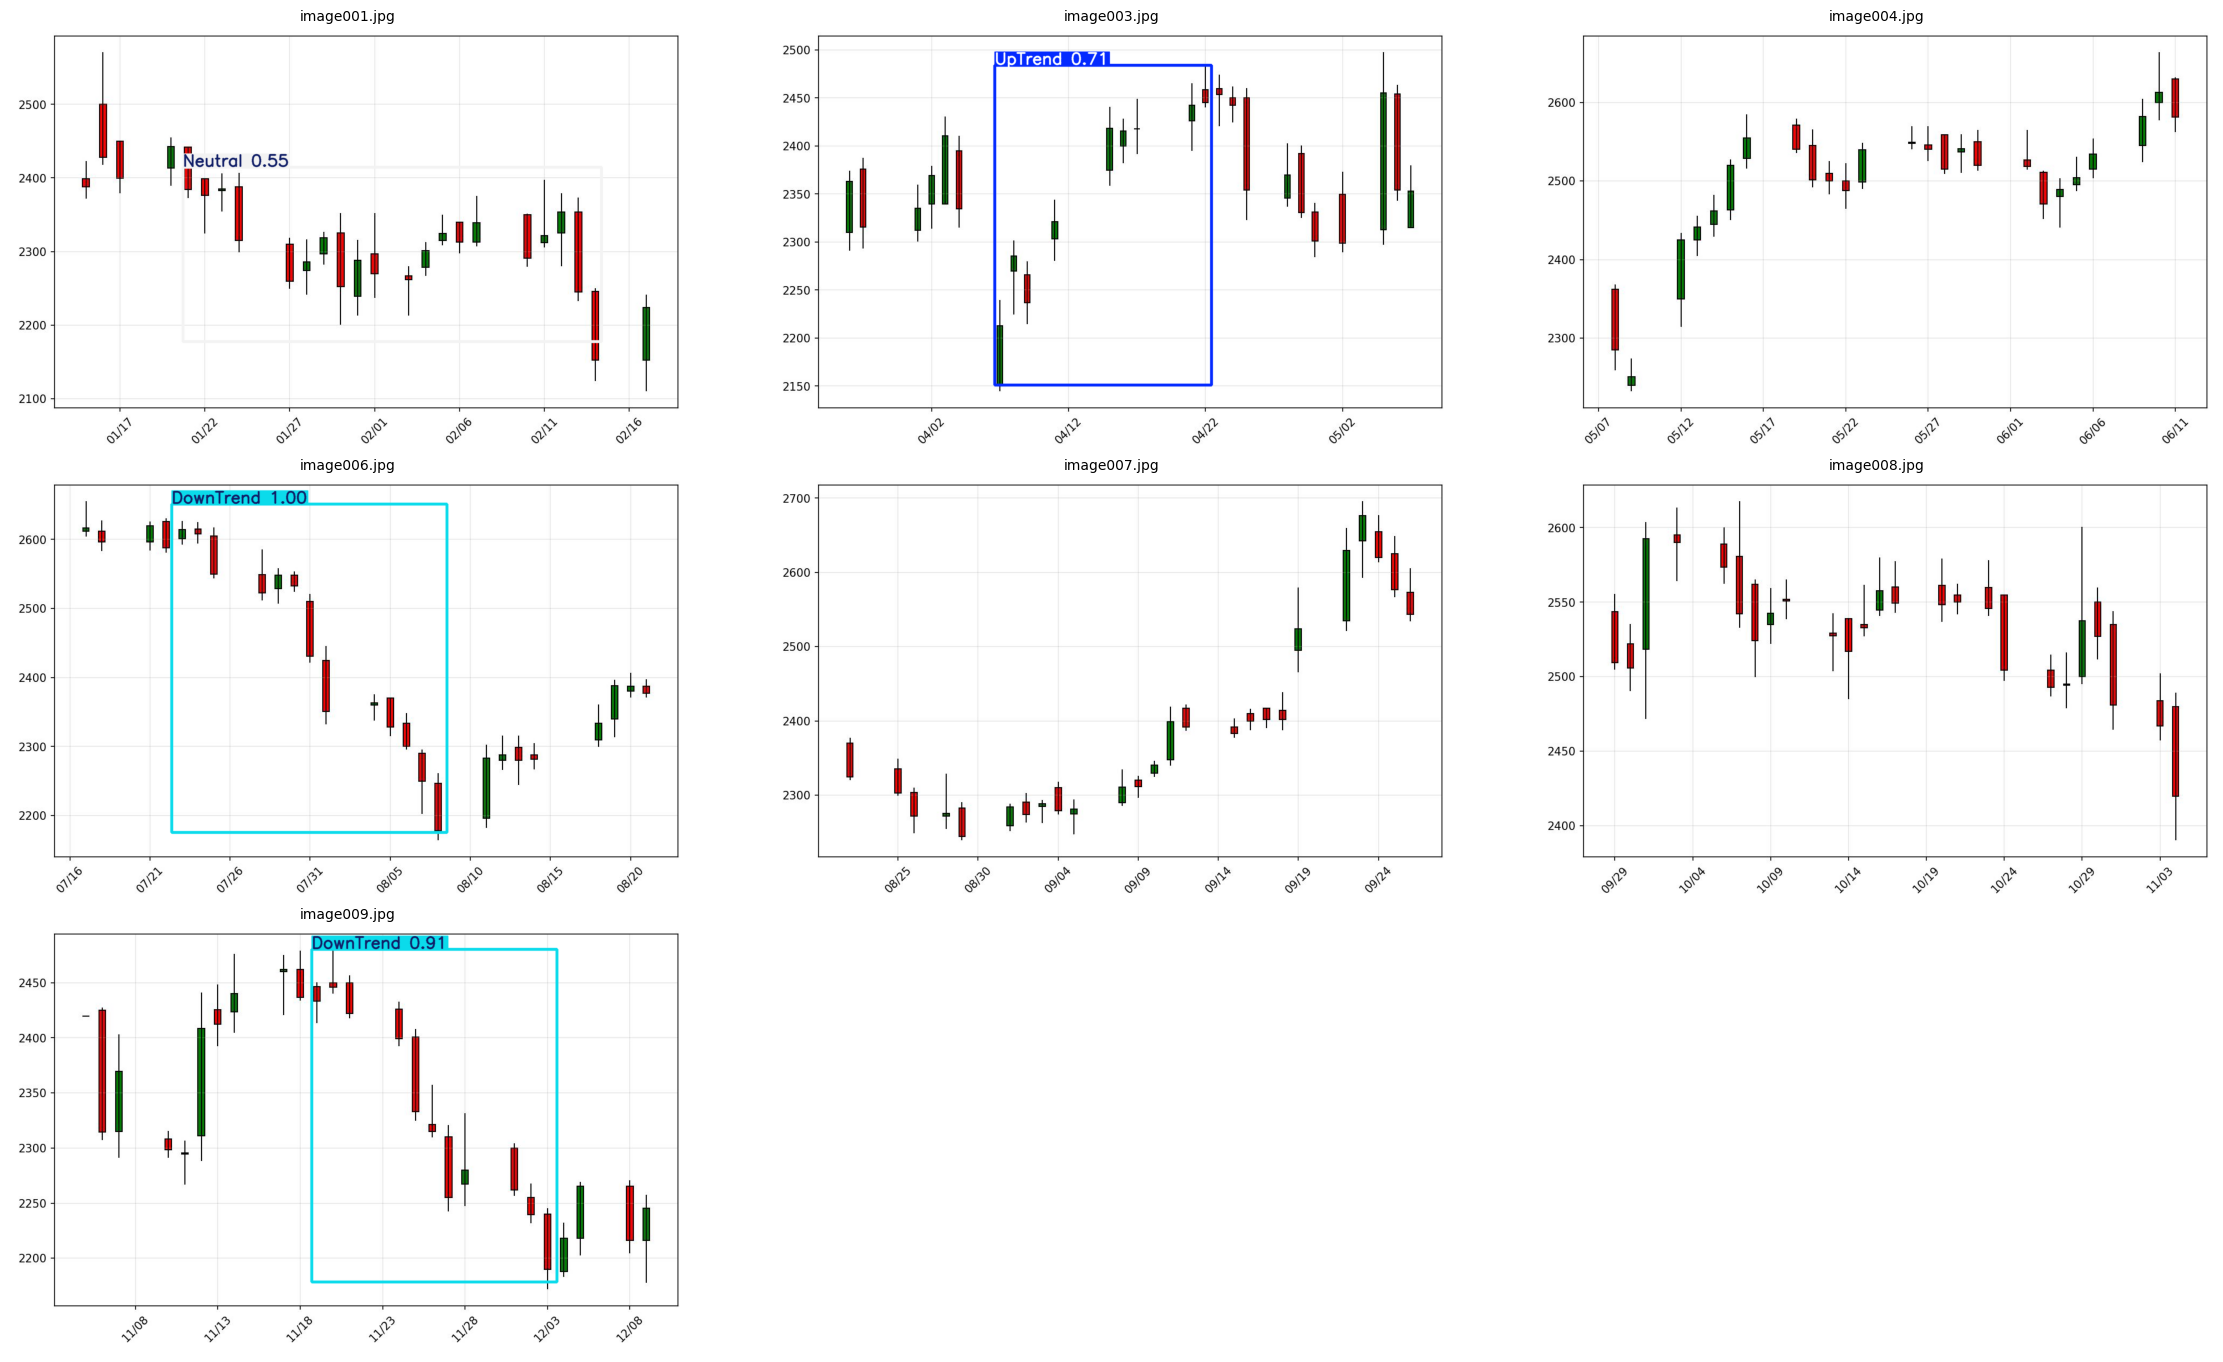

In [23]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("best8s.pt")

image_paths = [
    "test_images/image001.jpg",
    "test_images/image003.jpg",
    "test_images/image004.jpg",
    "test_images/image006.jpg",
    "test_images/image007.jpg",
    "test_images/image008.jpg",
    "test_images/image009.jpg"
]

results = model(image_paths)

plt.figure(figsize=(23, 18))  

rows, cols = 4, 3

for i, (r, path) in enumerate(zip(results, image_paths), start=1):
    img = r.plot()[:, :, ::-1]  # BGR -> RGB
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(path.split("/")[-1], fontsize=10)

plt.tight_layout(pad=0.3, w_pad=0.1, h_pad=0.3)
plt.show()
